# Práctica 11 — Segmentación de Clientes de Centro Comercial (Clustering K-Means)
**Programa de Estudios:** Ingeniería en Desarrollo y Gestión de Software \
**Asignatura:** Extracción de Conocimiento en Bases de Datos \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Unidad:** 4 \
**Periodo:** Mayo - Agosto 2026 \
**Fecha de entrega:** 15 de agosto de 2026

**Objetivo:** Clasificar / agrupar a los clientes de un centro comercial en función de características numéricas y categóricas, aplicando el algoritmo de **Clustering K-Means** (Aprendizaje No Supervisado).

**Nombre del Estudiante:** Karen Lizbeth Negrete Hernández \
**Matrícula:** 230570 \
**Grado y Grupo:** 9° B IDGS \
**Repositorio de Git:** https://github.com/karenNegrete06/ECBD_9B_IDGS_Practicas_230570.git

### Contenido del Notebook :
- Información del Dataset
- Análisis Exploratorio de Datos (EDA)
- Resumen del EDA
- Ingeniería de Características
- Modelado
- Conclusión

### Lo que aprenderás :
- Técnicas de visualización de datos.
- Información sobre el algoritmo de Clustering K-Means.
- Pruebas estadísticas para la selección de hiperparámetros.
- Diferencia en el rendimiento del modelo al entrenarlo con el dataset original y el normalizado.

### Trabajo Reciente :

- [Clasificación Binaria](https://www.kaggle.com/competitions/titanic/discussion/352223) **: Describe el enfoque necesario para tratar problemas de Clasificación Binaria, explicado a través de notebooks que contienen trabajo realizado sobre datasets con código fácil de entender.**
- [Análisis de Series de Tiempo](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/discussion/352205) **: Describe los fundamentos del Análisis de Series de Tiempo, explicado a través de notebooks que contienen trabajo realizado sobre datasets con código fácil de entender.**



# <center>Información del Dataset</center>

### Importar las Librerías Necesarias :

In [42]:
import os
os.environ['OMP_NUM_THREADS'] = '1'  # Evita el warning de fuga de memoria de KMeans con MKL en Windows

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [3]:
datos = pd.read_csv('Mall_Customers.csv')
datos.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Información de los Datos :

In [4]:
datos.shape

(200, 5)

In [5]:
datos.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [41]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


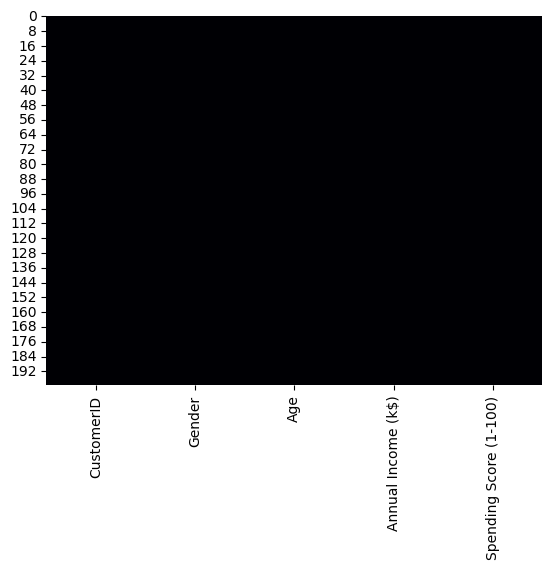

In [40]:
sns.heatmap(datos.isnull(),cmap = 'magma',cbar = False);

- **No hay valores nulos** presentes en los datos!

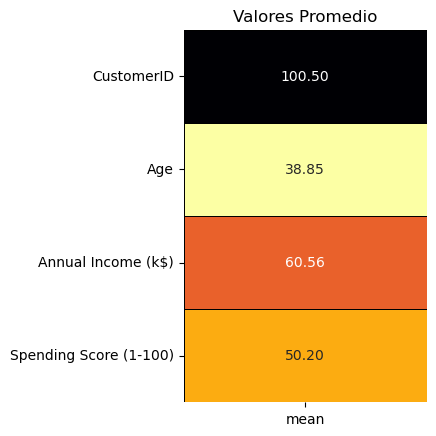

In [8]:
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))

plt.subplot(1,1,1)
sns.heatmap(datos.describe().T[['mean']],cmap = 'inferno_r',annot = True,fmt = '.2f',linecolor = 'black',linewidths = 0.4,cbar = False);
plt.title('Valores Promedio');

fig.tight_layout(pad = 3)

- La **Edad (Age)** promedio del cliente en el dataset se encuentra en los últimos años de la treintena, es decir **38.85**.
- El **Ingreso Anual (k\$)** promedio de los clientes es **60.56**, es decir, ligeramente por debajo de la mediana de ingresos de 2018 de un ciudadano de EE.UU., 63k$.
- El promedio del **Puntaje de Gasto (1-100)** del cliente del centro comercial está en el centro, con **50.20**.

# <center>Análisis Exploratorio de Datos</center>

### Dividiendo las características en Numéricas y Categóricas :

In [9]:
columnas = list(datos.columns)
caracteristicas_categoricas = []
caracteristicas_numericas = []
for i in columnas:
    if len(datos[i].unique()) > 6:
        caracteristicas_numericas.append(i)
    else:
        caracteristicas_categoricas.append(i)

print('Características Categóricas :',*caracteristicas_categoricas)
print('Características Numéricas :',*caracteristicas_numericas)

Características Categóricas : Gender
Características Numéricas : CustomerID Age Annual Income (k$) Spending Score (1-100)


- Aquí, las características categóricas se definen si el atributo tiene menos de 6 elementos únicos; en caso contrario, es una característica numérica.
- El enfoque típico para esta división de características también puede basarse en los tipos de datos de los elementos del atributo respectivo.

**Ej :** tipo de dato = entero, atributo = característica numérica ; tipo de dato = texto, atributo = característica categórica

- Para este dataset, como el número de características es reducido, también podemos revisar el dataset manualmente.

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = datos.copy(deep = True)

df1['Gender'] = le.fit_transform(df1['Gender'])

print('Transformación con Label Encoder')
print(df1['Gender'].unique(),' = ',le.inverse_transform(df1['Gender'].unique()))

Transformación con Label Encoder
[1 0]  =  ['Male' 'Female']


- Se crea una copia profunda del dataset original y se codifica (label encoding) el texto de **Gender**.
- Las modificaciones en el dataset original no se reflejarán en esta copia profunda.
- Por lo tanto, usamos esta copia profunda del dataset que tiene **Gender** convertido a valores numéricos, para fines de visualización y modelado.

### Distribución de las Características Categóricas y Numéricas :

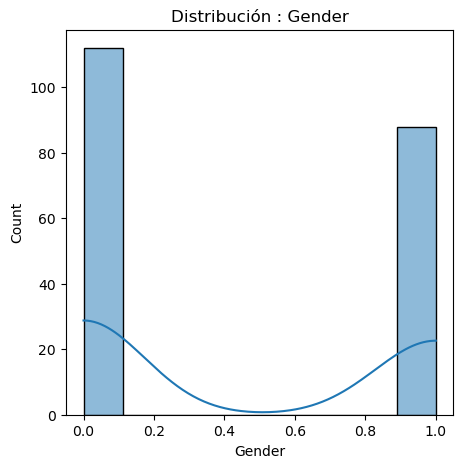

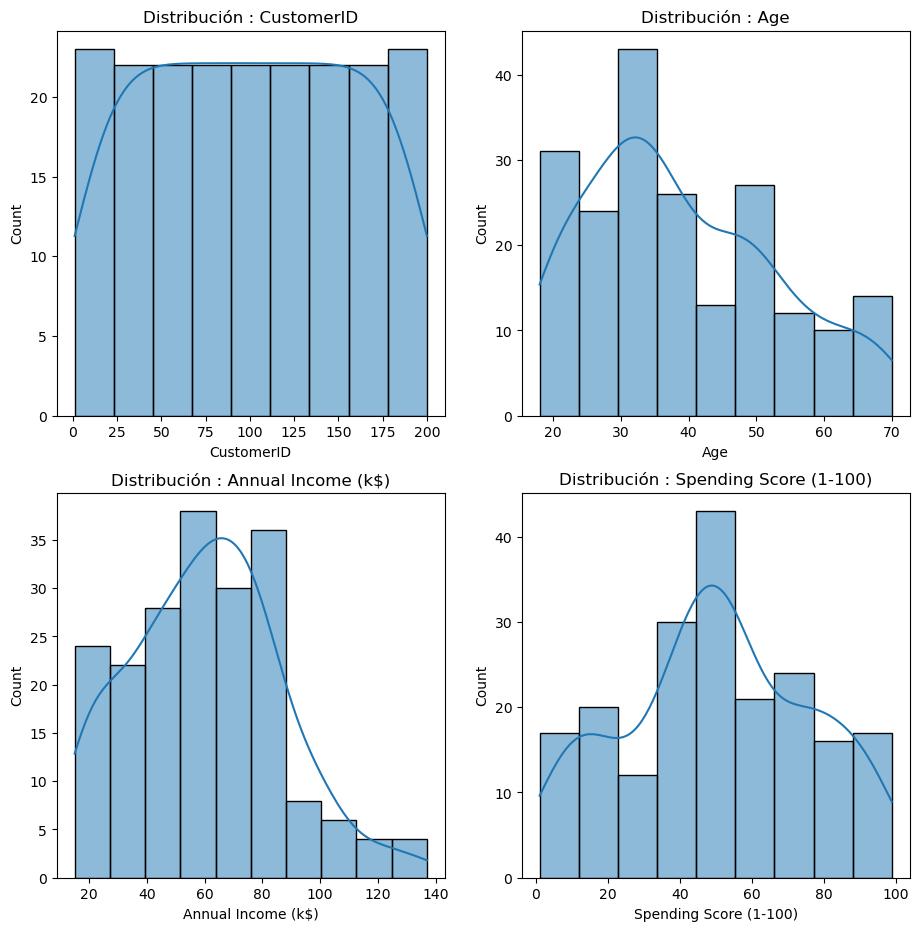

In [11]:
fig, ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))
for i in range(len(caracteristicas_categoricas)):
    plt.subplot(1,1,i+1)
    sns.histplot(df1[caracteristicas_categoricas[i]],kde = True);
    titulo = 'Distribución : ' + caracteristicas_categoricas[i]
    plt.title(titulo)
    
fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(caracteristicas_numericas)):
    plt.subplot(2,2,i+1)
    sns.histplot(datos[caracteristicas_numericas[i]],kde = True)
    titulo = 'Distribución : ' + caracteristicas_numericas[i]
    plt.title(titulo)
plt.show()

- **Gender**, la única característica categórica, muestra una **distribución normal**.
- La distribución de **Age** e **Annual Income (k\$)** es **positivamente o hacia la derecha sesgada**.
- La distribución de **Spending Score (1-100)** es similar al patrón **"Cabeza y Hombros"** observado en los gráficos bursátiles.
- Muestra el precio de una acción subiendo hasta un pico y luego bajando de nuevo a la base del movimiento alcista previo. Se puede observar algo similar con los **2 hombros** formándose alrededor de los valores **20 y 80**, con la **cabeza** centrada entre **40 - 60**.
- Eliminaremos la característica **CustomerID**, ya que es solo un número asignado a un cliente.

In [12]:
caracteristicas_numericas.remove('CustomerID')

### Características Categóricas :

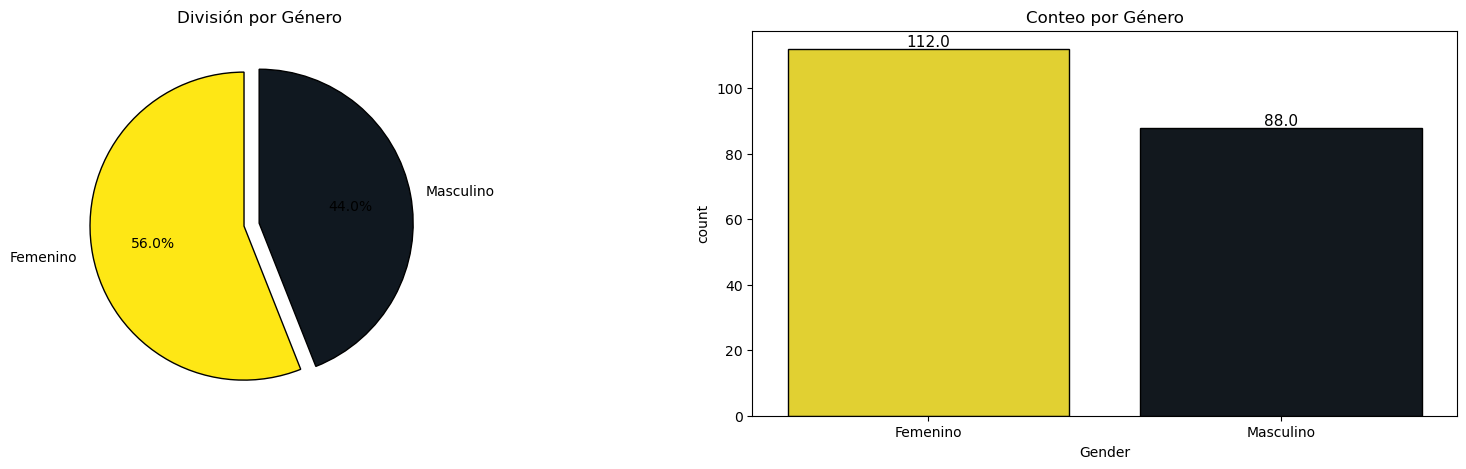

In [13]:
l = list(datos['Gender'].value_counts())
circulo = [l[0] / len(l) * 100, l[1] / len(l) * 100]
colores = ['#FEE715','#101820']

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))

plt.subplot(1,2,1)
plt.pie(circulo,labels = ['Femenino','Masculino'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colores,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('División por Género');

plt.subplot(1,2,2)
ax = sns.countplot(x = 'Gender',hue = 'Gender',data = df1,palette = colores,edgecolor = 'black',legend = False);
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.75, rect.get_height(), horizontalalignment='center', fontsize = 11)
plt.title('Conteo por Género')
ax.set_xticks([0,1])
ax.set_xticklabels(['Femenino','Masculino'])

plt.show()

- Para el dataset anterior, las clientas **femeninas** superan por poco a los clientes **masculinos**.

### Características Numéricas vs Características Categóricas :

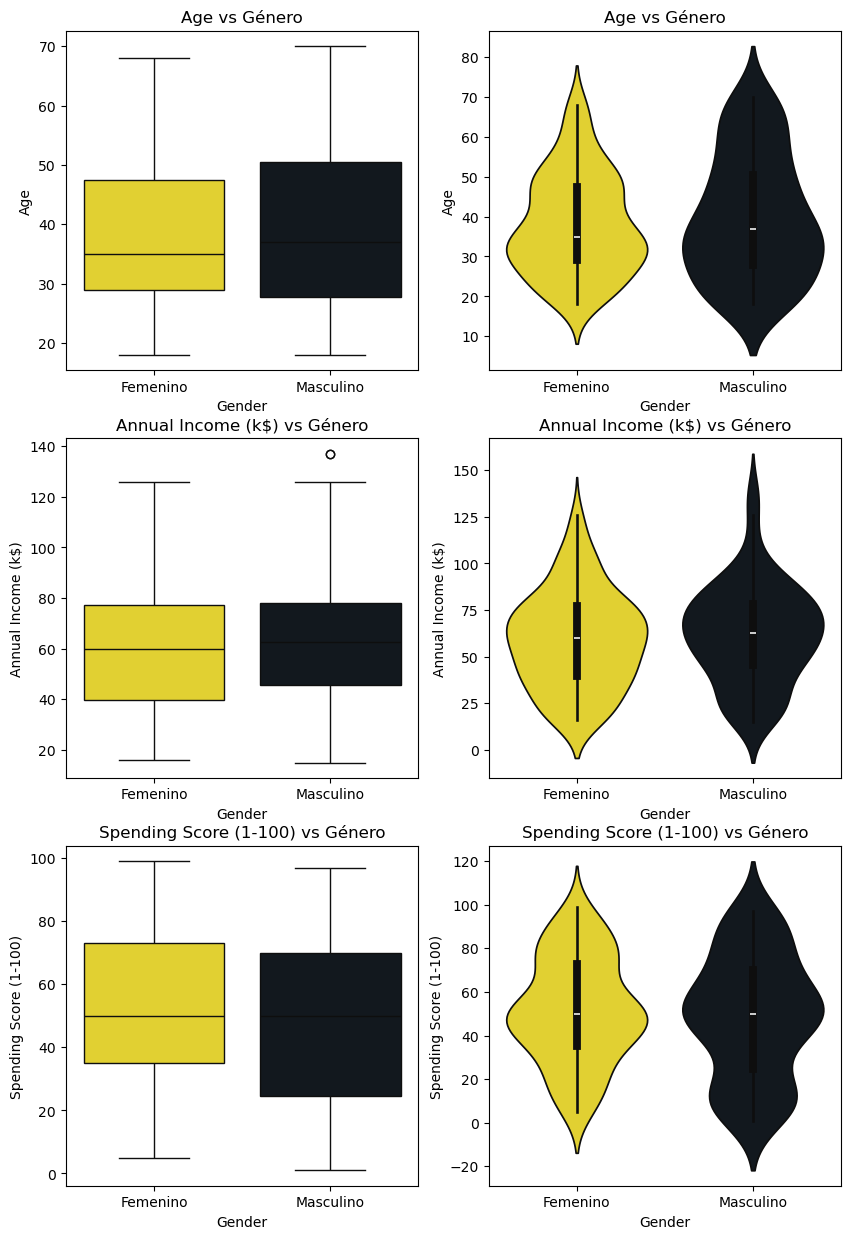

In [14]:
fig = plt.subplots(nrows = 3,ncols = 2,figsize = (10,15))
for i in range(len(caracteristicas_numericas)):
    plt.subplot(3,2, (i * 2)  + 1)
    ax = sns.boxplot(x = 'Gender',y = caracteristicas_numericas[i],hue = 'Gender',palette = colores,data = df1,legend = False)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Femenino','Masculino'])
    titulo = caracteristicas_numericas[i] + ' vs Género'
    plt.title(titulo)
    
    plt.subplot(3,2,(i * 2) + 2)
    ax = sns.violinplot(x = 'Gender',y = caracteristicas_numericas[i],hue = 'Gender',palette = colores,data = df1,legend = False)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Femenino','Masculino'])
    titulo = caracteristicas_numericas[i] + ' vs Género'
    plt.title(titulo)

- El rango de **Age** de las clientas **femeninas** va de **30 a poco menos de 50**, mientras que el de los clientes **masculinos** va de **poco menos de 30 a 50**.
- Para ambos **géneros** se observa un aumento en la edad de **30 - 35**. La mediana de **Age** de los **hombres** es ligeramente mayor que la de las **mujeres**.
- Para **Annual Income (k\$)**, el ingreso de las clientas **femeninas** comienza en **40k**, mientras que el de los clientes **masculinos** está por encima de ese valor.
- La mediana de **Annual Income (k\$)** para ambos **géneros** es de aproximadamente **60k**. El **Annual Income (k\$)** de los clientes **masculinos** se estrecha muy bruscamente en la parte superior, con algunos valores atípicos en comparación con las clientas **femeninas**.
- La mediana del **Spending Score (1-100)** de ambos **géneros** es la misma, a pesar de tener distintos puntos de partida: **poco menos de 40** y **poco más de 20** para clientas **femeninas** y clientes **masculinos** respectivamente.
- Ambos **géneros** muestran un fuerte pico en el valor de la mediana, especialmente las clientas **femeninas**. Sin embargo, los clientes **masculinos** muestran un pico pequeño pero significativo en el rango de **0 - 20** también.

### Características Numéricas vs Características Numéricas respecto a la Característica Categórica :

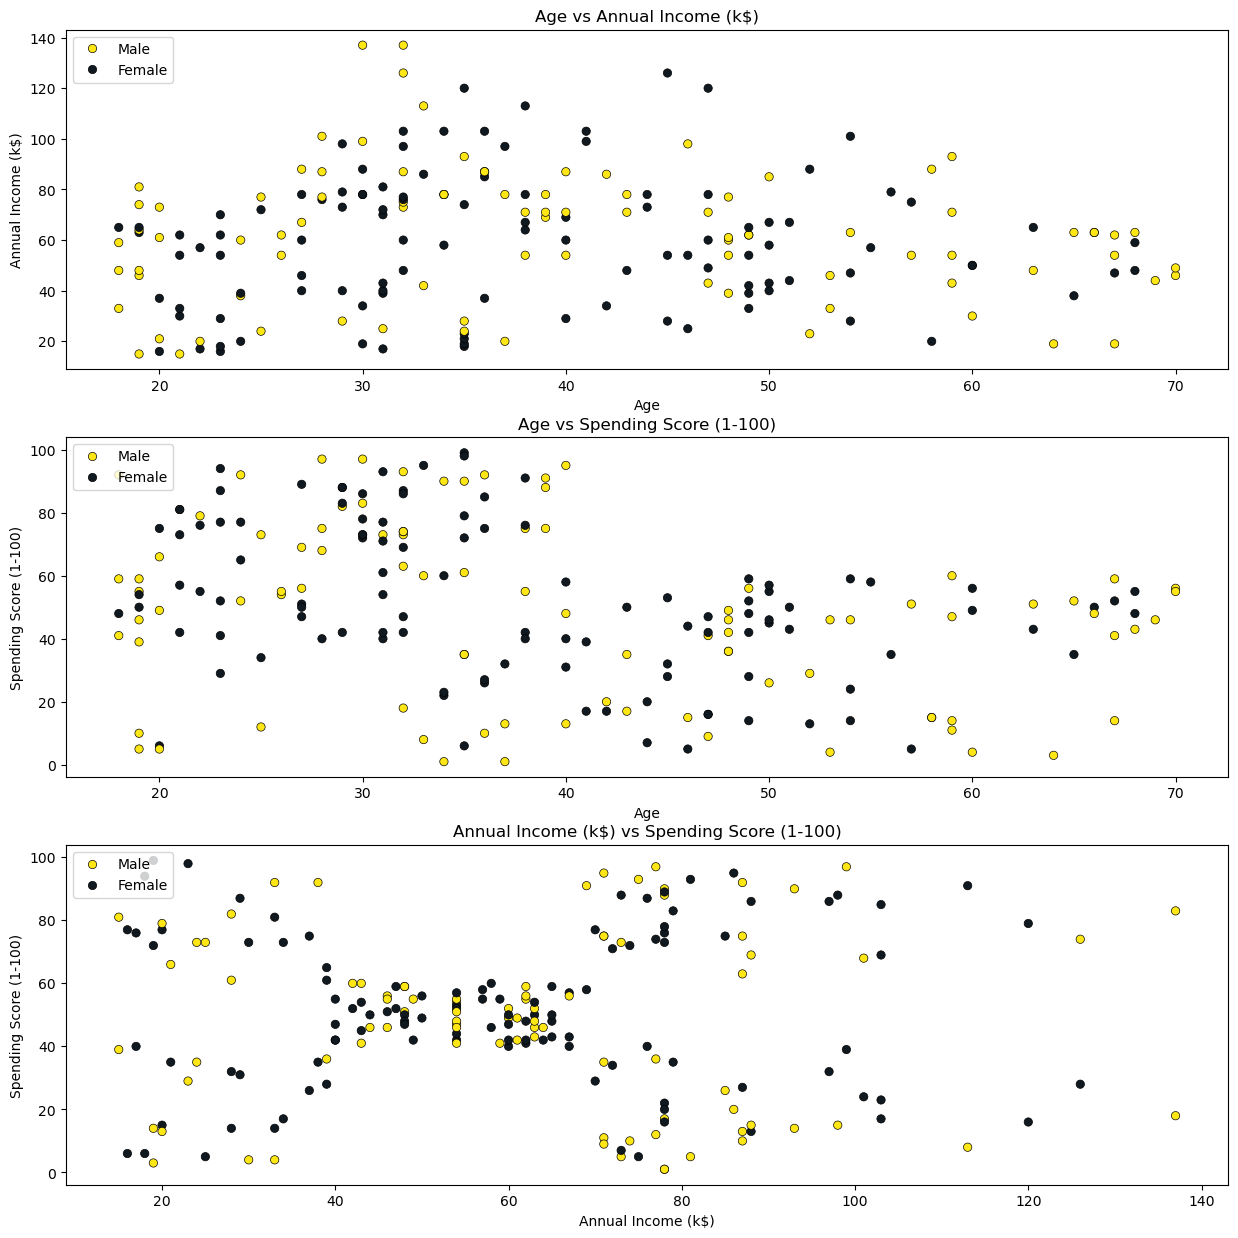

In [15]:
a = 0
fig,ax = plt.subplots(nrows = 3,ncols = 1,figsize = (15,15))
for i in range(len(caracteristicas_numericas) - 1):
    for j in range(len(caracteristicas_numericas)):
        if i != j and j > i:
            a += 1
            plt.subplot(3,1,a)
            sns.scatterplot(x = caracteristicas_numericas[i],y = caracteristicas_numericas[j],data = datos,
                            hue = 'Gender',palette = colores,edgecolor = 'black');
            plt.legend(loc = 'upper left',)
            titulo = caracteristicas_numericas[i] + ' vs ' + caracteristicas_numericas[j]
            plt.title(titulo)

- Los puntos de datos de **Annual Income (k\$)** están presentes en todos los valores de **Age**; **Gender** no aporta información significativa.
- Para **Spending Score (1-100)**, se observa claramente que las edades entre **20 - 30** muestran hábitos de gasto muy altos.
- El grupo de **Age** entre **30 - 40** destaca ambos extremos de los hábitos de gasto del cliente. El grupo de **Age** entre **40 - 70** muestra el otro extremo, con valores bajos.
- En **Annual Income (k\$) vs Spending Score (1-100)** se pueden observar 5 grupos claramente diferenciados. Para valores de **Annual Income (k\$)** entre **0 - 40**, los datos muestran 2 grupos de clientes con **Spending Score (1-100)** entre **0 - 40** y **60 - 100**.
- Después de este primer extremo, los datos muestran el grupo medio de clientes que tienen un **Annual Income (k\$)** entre **40 - 70k** y un **Spending Score (1-100)** entre **40 - 60**.
- Los valores de **Annual Income (k\$)** entre **70 - 140k** definen el otro extremo, que se divide en 2 grupos según los valores de **Spending Score (1-100)** de **0 - 40** y **60 - 100**.

# <center>Resumen del EDA</center>

- Para los datos del centro comercial anterior, las clientas **femeninas** son más numerosas que los clientes **masculinos**. Los datos de **Gender** están bastante distribuidos de manera uniforme respecto a las demás características.
- Los clientes del centro comercial pueden dividirse según sus grupos de **Age** :
    - **20 - 30**
    - **30 - 40**
    - **40 - 70**.
- La mediana de **Annual Income (k\$)** de ambos **géneros** es de aproximadamente **60k**. Muestra 3 grupos de valores :
    - **0 - 40k**
    - **40 - 70k**
    - **70 - 140k**.
- El **Spending Score (1-100)** de las **mujeres** es mayor que el de los clientes **hombres**. También puede dividir a los clientes en 3 grupos :
    - **0 - 40**
    - **40 - 60**
    - **60 - 100**
- Usando la combinación de los valores anteriores, los **Clientes del Centro Comercial** pueden segmentarse y así atenderlos de manera específica.

# <center>Ingeniería de Características</center>

### Matriz de Correlación :

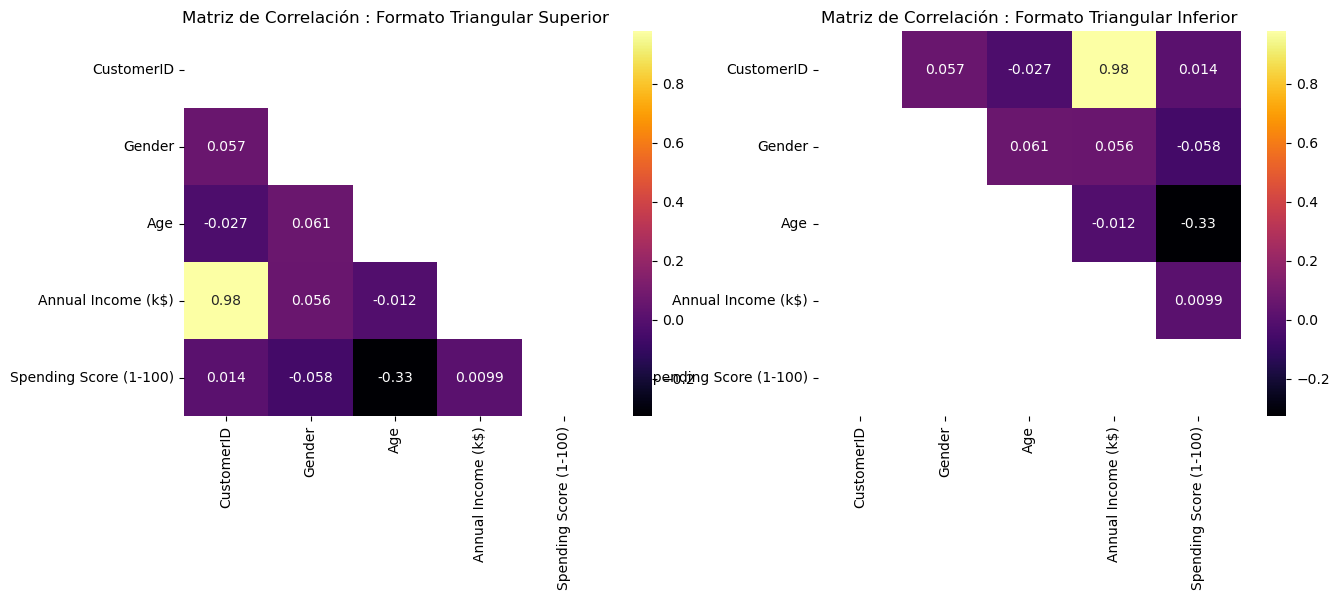

In [16]:
ut = np.triu(df1.corr())
lt = np.tril(df1.corr())

fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = ut);
plt.title('Matriz de Correlación : Formato Triangular Superior');

plt.subplot(1,2,2)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = lt);
plt.title('Matriz de Correlación : Formato Triangular Inferior');

df1.drop(columns = 'CustomerID',inplace = True)

- ¡Ambas matrices mostradas son la misma! Solo se hace con fines de visualización. Este truco puede usarse cuando el dataset tiene demasiadas características para revisar.
- **CustomerID** muestra una correlación positiva muy alta con **Annual Income (k\$)**, ya que los clientes están ordenados de forma ascendente según su **Annual Income (k\$)**. No vamos a incluir **CustomerID** para el modelado.
- **Gender** no muestra ninguna relación con las demás características. Es bastante neutral, con todos los valores cercanos a 0.
- **Spending Score (1-100)** y **Age** muestran una correlación negativa, es decir, si el valor de una característica aumenta, el valor de la otra disminuye, y viceversa.
- Esta información se obtuvo en la sección de **EDA**; los valores de la matriz de correlación respaldan aún más esa evidencia.
- Ahora pasaremos a la sección de modelado, creando combinaciones de estas características y encontrando distintas maneras en que los clientes del centro comercial pueden ser segmentados.

### Escalado de Datos :

- El modelo de aprendizaje automático no entiende las unidades de los valores de las características. Trata la entrada simplemente como un número, pero no comprende el verdadero significado de ese valor. Por lo tanto, es necesario escalar los datos.

- Tenemos 2 opciones para el escalado de datos :
    
    1) **Normalización**
    
    2) **Estandarización**.


- Como la mayoría de los algoritmos asumen que los datos siguen una distribución normal (Gaussiana), se realiza la **Normalización** para las características que no muestran una distribución normal, y se lleva a cabo la **Estandarización** para las características que sí son normales pero cuyo rango de valores es muy grande o muy pequeño comparado con otras características.

- Para el dataset anterior, hemos realizado la **Normalización** de 3 características: **Age**, **Annual Income (k\$)** y **Spending Score (1-100)**. La característica **Gender** se deja sin modificar.

In [17]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalización
ss = StandardScaler() # Estandarización

# Codificación de etiquetas (Label Encoding)
df2 = df1.copy(deep = True)

# Normalización
df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

- Para resaltar la diferencia entre el rendimiento de los modelos al entrenarlos con el dataset original y con el dataset normalizado, creamos una copia del dataset original y le aplicamos la transformación de normalización.

**¡Ahora pasaremos a la sección de modelado!**

# <center>Modelado</center>

- **Aprendizaje No Supervisado** : Es un problema donde la variable / característica objetivo es desconocida. Los problemas de **Aprendizaje No Supervisado** ocurren ampliamente en el ámbito médico, donde se toman múltiples mediciones y se desconocen las enfermedades subyacentes.
- Por lo tanto, buscar patrones mediante técnicas de visualización nos brinda información subyacente que no se puede comprender simplemente observando los datos tabulares.
- Sin embargo, cuando el tamaño de los datasets se vuelve enorme, con demasiadas características, la visualización de datos puede convertirse en una tarea tediosa. Por eso recurrimos al algoritmo de **Clustering K-Means**, el cual **no admite características categóricas**.
- Es el algoritmo más preferido para tratar el **Aprendizaje No Supervisado**, que realiza la tarea de encontrar clusters / grupos en los datos, pero con un enfoque matemático :
    - Selecciona 2 (suponiendo k = 2) centroides al azar.
    - Se calcula la distancia entre los centroides y todos los puntos de datos.
    - Si el punto de datos está más cerca de uno de los centroides, se etiqueta con ese centroide, y viceversa.
    - Para los 2 clusters formados, se calcula el valor promedio de los puntos de datos agrupados con cada centroide, y esos valores promedio se definen como los nuevos clusters.
    - Este proceso se repite hasta que ambos centroides convergen en puntos fijos.
- **Hiperparámetro k** : Define el número de clusters o grupos en los que se dividirán los datos. Para la selección de los valores de **k**, usamos 2 pruebas estadísticas :
    - **Método del Codo (Elbow Method)** : Es un método que grafica la suma de errores al cuadrado para un rango de valores de **k**. Si esta gráfica se parece a un brazo, se selecciona el valor de **k** que se asemeja a un **codo**. A partir de este valor de **codo**, la suma de los valores al cuadrado (inercia) comienza a disminuir de forma lineal, por lo que se considera un valor óptimo.
    - **Método del Puntaje de Silueta (Silhouette Score)** : Es un método que evalúa la calidad de los clusters en función de qué tan bien están agrupados los puntos de datos con otros puntos de datos similares entre sí. Este puntaje se calcula usando la fórmula de distancia, y se selecciona el valor de **k** con el puntaje más alto para el modelado.
    
**Ahora crearemos modelos entrenándolos con la combinación de características seleccionadas a partir de las pruebas anteriores, y también los visualizaremos.**

In [18]:
# Eliminando la característica categórica
df1.drop(columns = 'Gender',inplace = True)
df2.drop(columns = 'Gender',inplace = True)

### <center>Age - Annual Income (k\$)</center>

In [19]:
m1 = df1[['Age','Annual Income (k$)']].values # Dataset Original
m2 = df2[['Age','Annual Income (k$)']].values # Dataset Normalizado

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

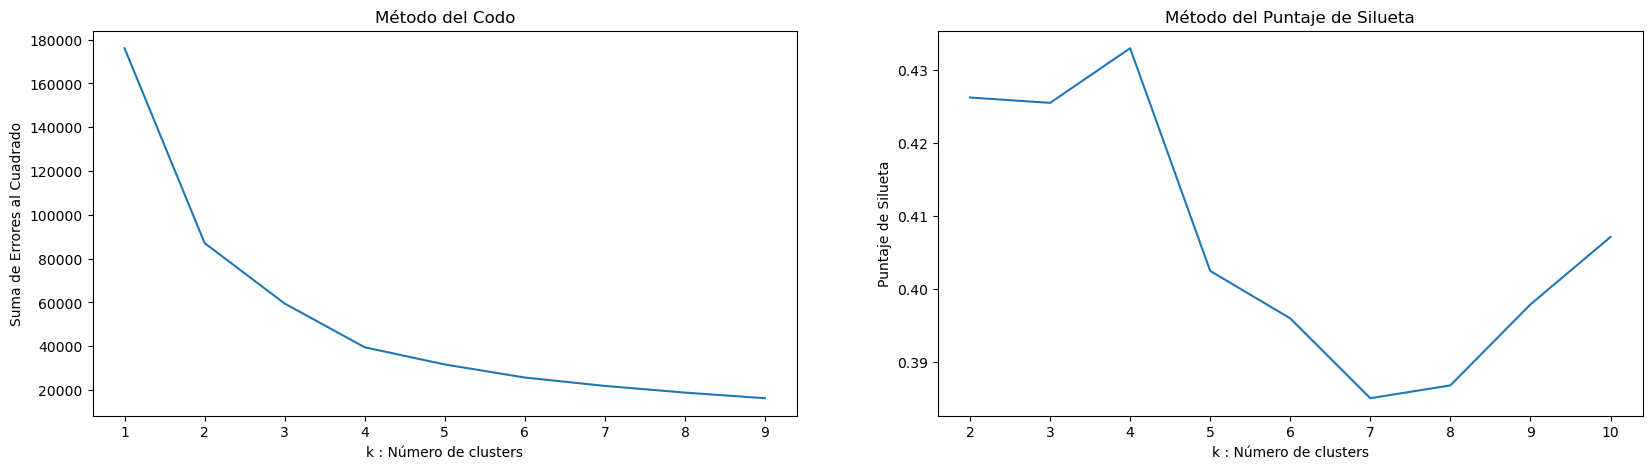

In [20]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 4**

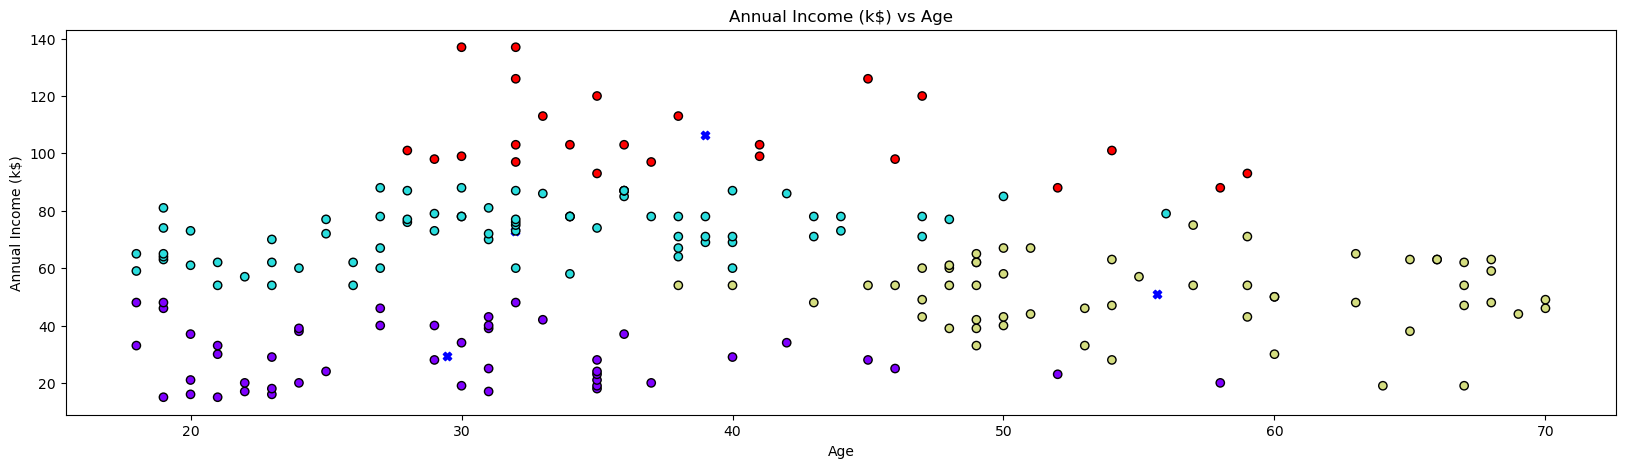

In [21]:
model = KMeans(n_init = 10, n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### Dataset Normalizado :

#### Método del Codo y Método del Puntaje de Silueta :

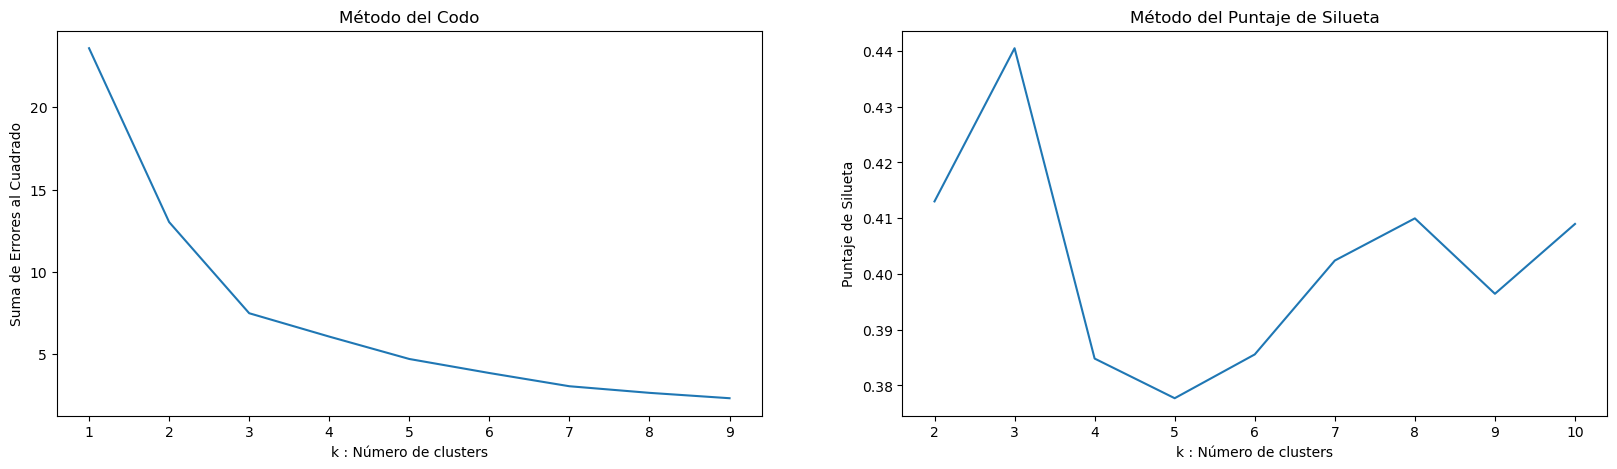

In [22]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 3**

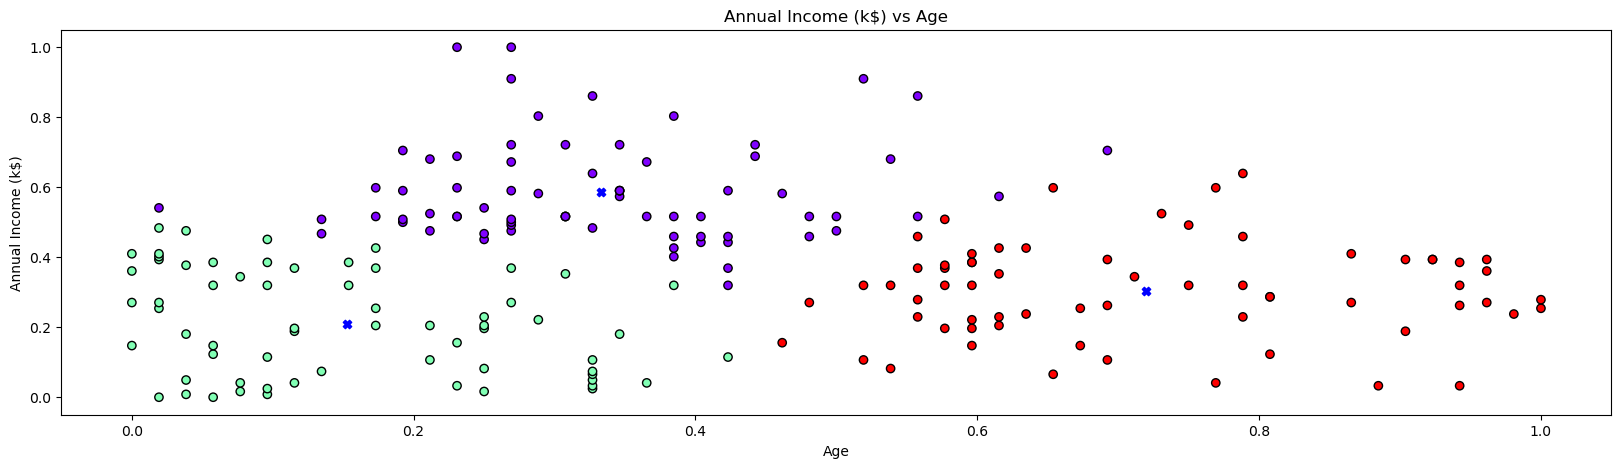

In [23]:
model = KMeans(n_init = 10, n_clusters = 3,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### <center>Age - Spending Score (1-100)</center>

In [24]:
m1 = df1[['Age','Spending Score (1-100)']].values # Dataset Original
m2 = df2[['Age','Spending Score (1-100)']].values # Dataset Normalizado

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

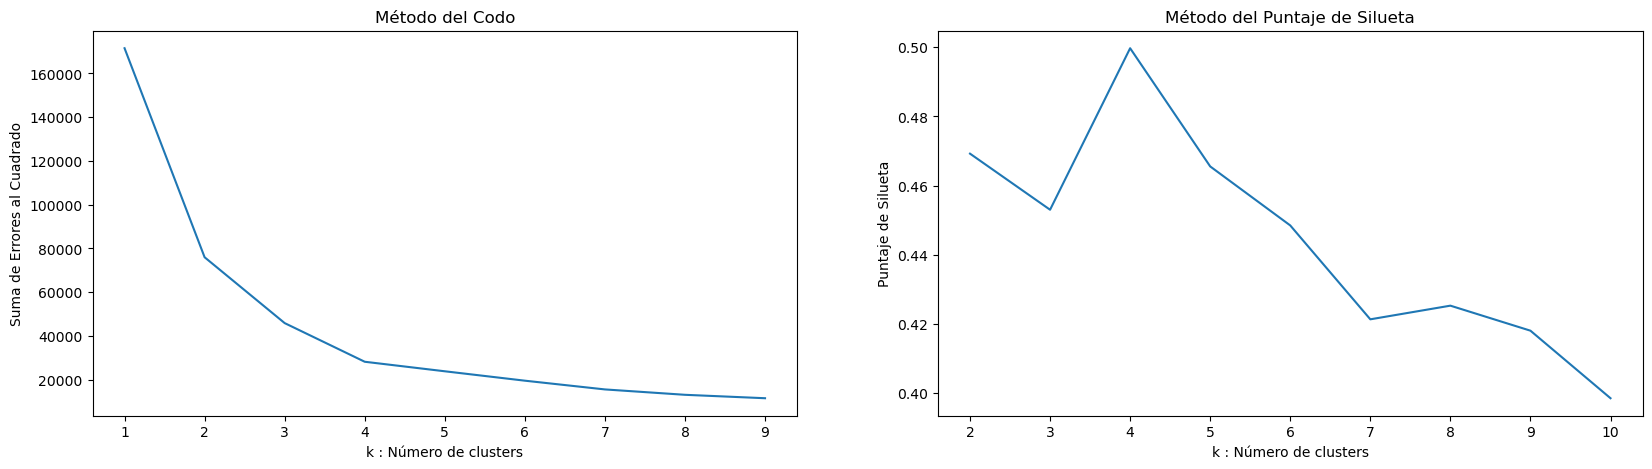

In [25]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 4**

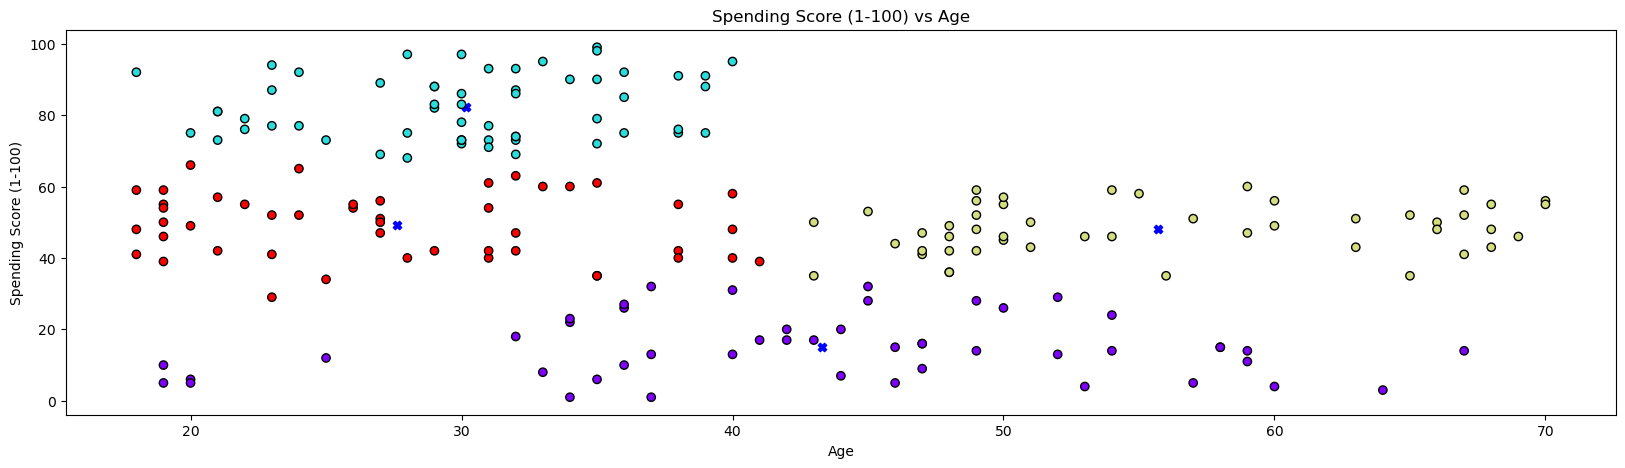

In [26]:
model = KMeans(n_init = 10, n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Dataset Normalizado :

#### Método del Codo y Método del Puntaje de Silueta :

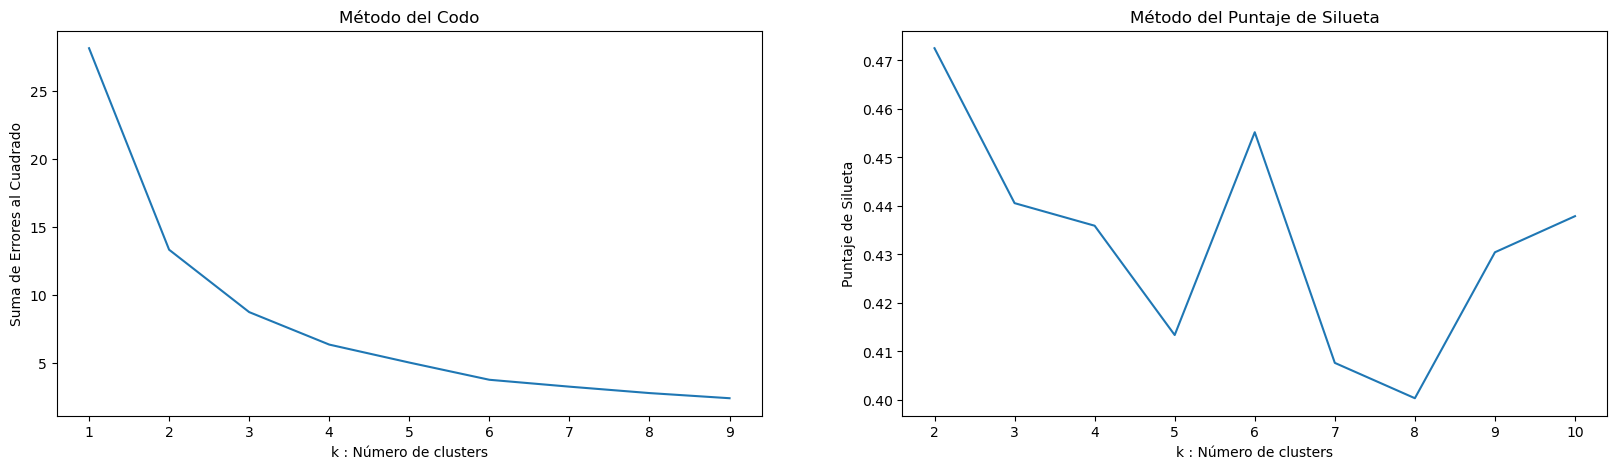

In [27]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 6**

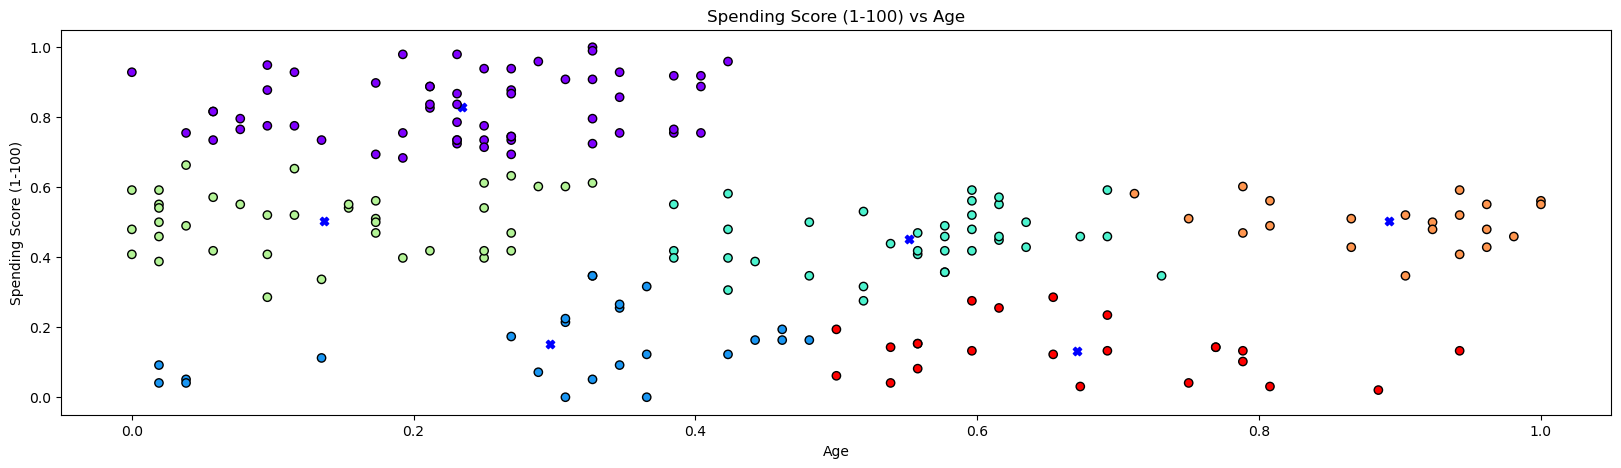

In [28]:
model = KMeans(n_init = 10, n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### <center>Annual Income (k\$) - Spending Score (1-100)</center>

In [29]:
m1 = df1[['Annual Income (k$)', 'Spending Score (1-100)']].values # Dataset Original
m2 = df2[['Annual Income (k$)', 'Spending Score (1-100)']].values # Dataset Normalizado

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

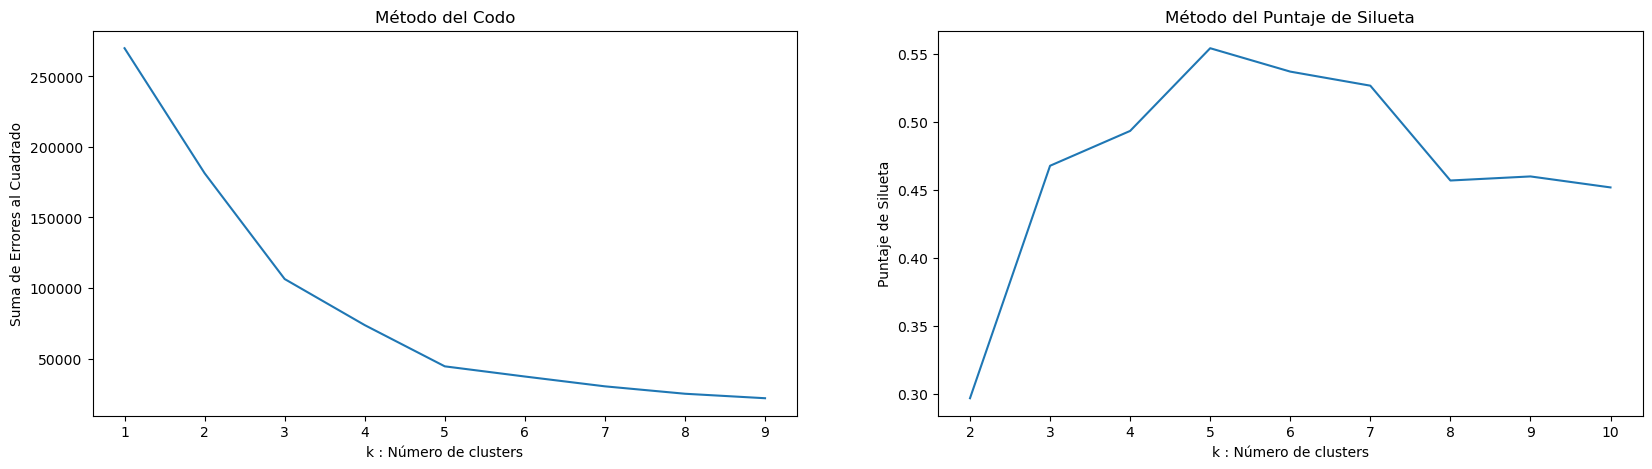

In [30]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 5**

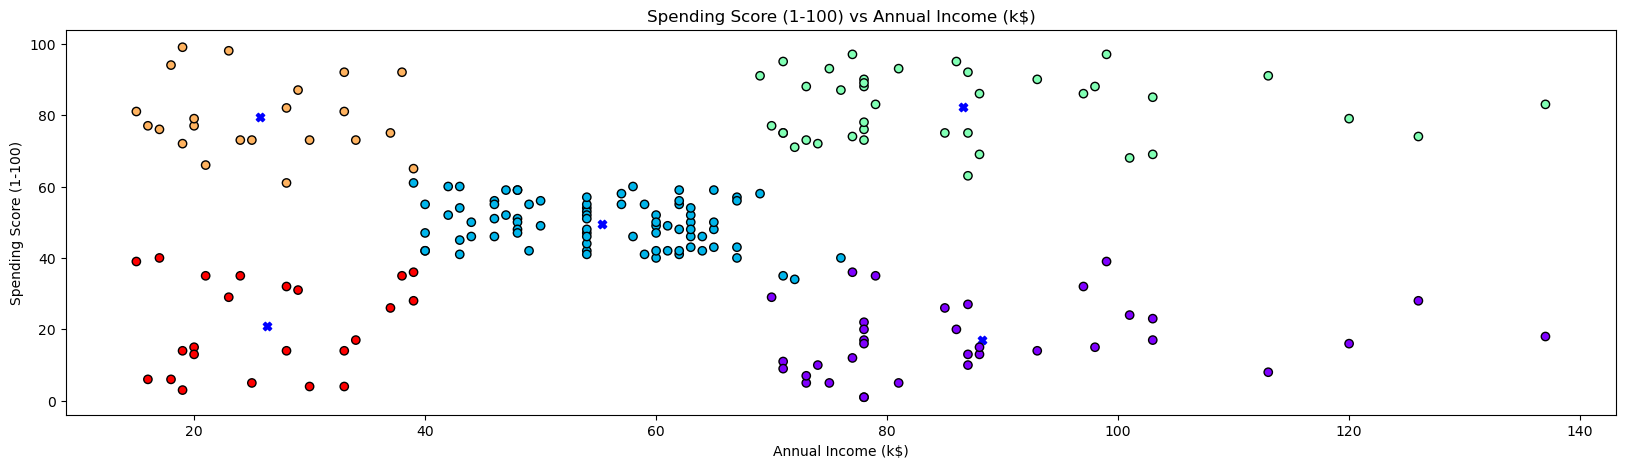

In [31]:
model = KMeans(n_init = 10, n_clusters = 5,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Dataset Normalizado :

#### Método del Codo y Método del Puntaje de Silueta :

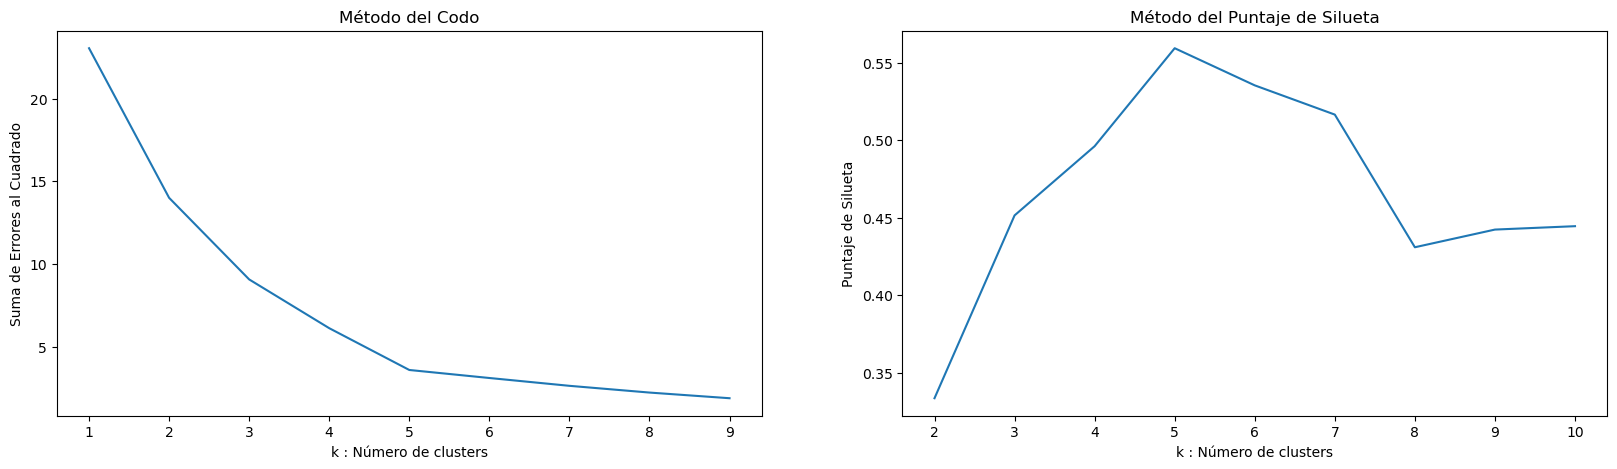

In [32]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 5**

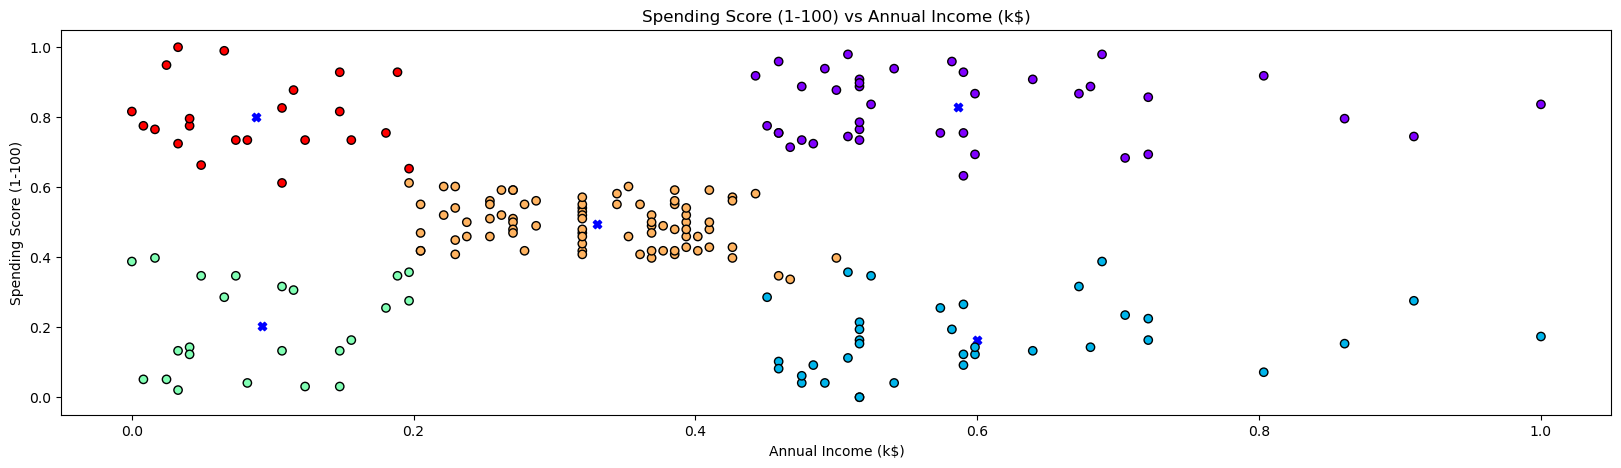

In [33]:
model = KMeans(n_init = 10, n_clusters = 5,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### <center>Age - Annual Income (k\$) - Spending Score (1-100)</center>

In [34]:
m1 = df1[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Dataset Original
m2 = df2[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Dataset Normalizado

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

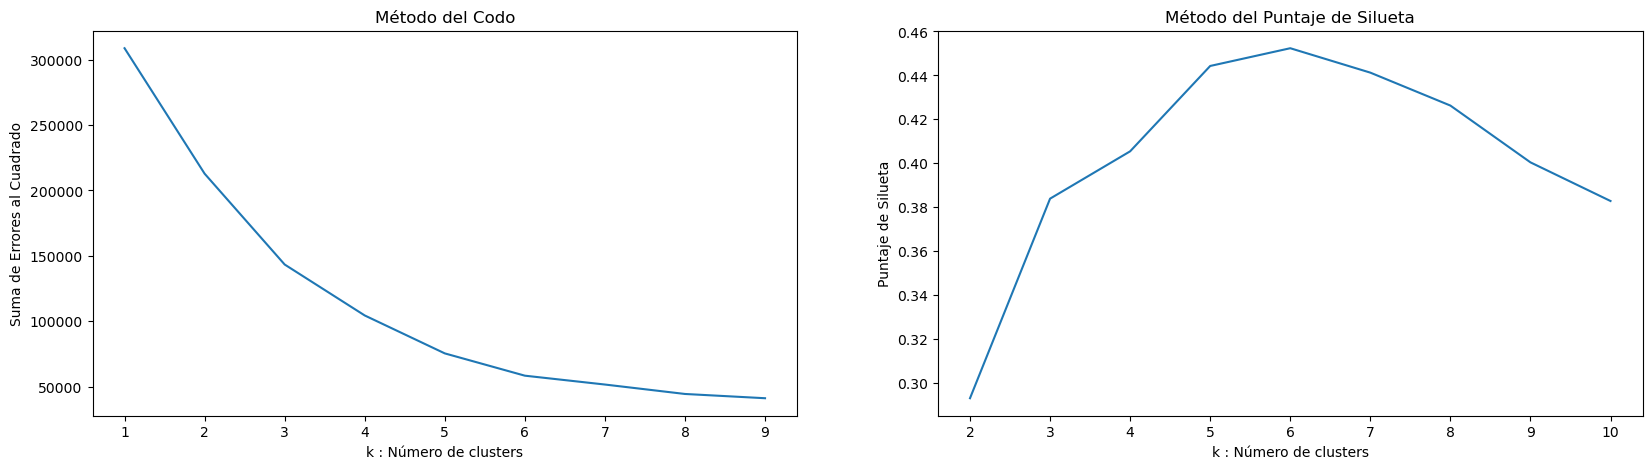

In [35]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 6**

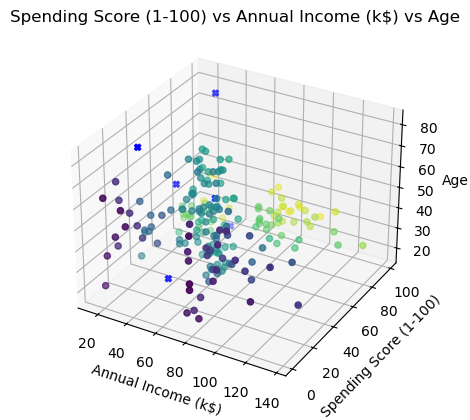

In [36]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = np.array(df1['Annual Income (k$)'])
y = np.array(df1['Spending Score (1-100)'])
z = np.array(df1['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker="X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

### Dataset Normalizado :

#### Método del Codo y Método del Puntaje de Silueta :

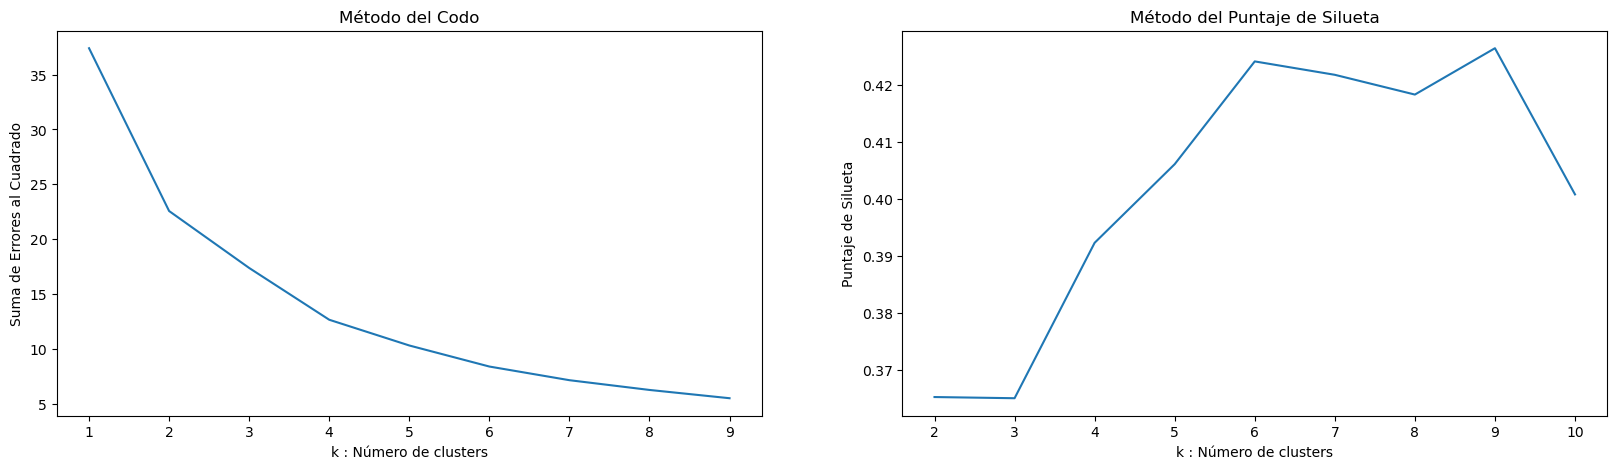

In [37]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del Codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_init = 10, n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inercia: Suma de las distancias de las muestras a su centro de cluster más cercano
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del Codo')
plt.xlabel("k : Número de clusters")
plt.ylabel("Suma de Errores al Cuadrado")

# Método del Puntaje de Silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_init = 10, n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método del Puntaje de Silueta')
plt.xlabel("k : Número de clusters")
plt.ylabel("Puntaje de Silueta")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clusters = 6**

In [38]:
!pip install ipympl

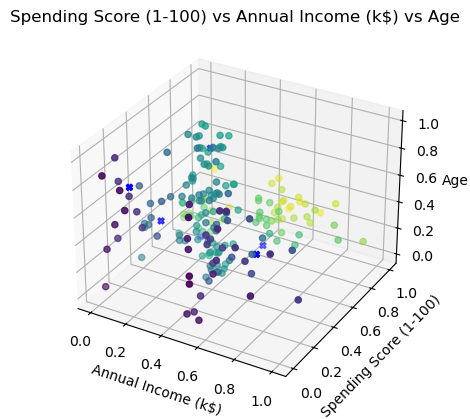

In [39]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = np.array(df2['Annual Income (k$)'])
y = np.array(df2['Spending Score (1-100)'])
z = np.array(df2['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker="X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

### <center>Tabla de Resultados</center>

#### Dataset Original :

|N°|Combinación de Características|Número de Clusters|
|-|-|-|
|1.|Age - Annual Income (k\$)|4|
|2.|Age - Spending Score (1-100)|4|
|3.|Annual Income (k\$) - Spending Score (1-100)|5|
|4.|Age - Annual Income (k\$) - Spending Score (1-100)|6|

#### Dataset Normalizado :

|N°|Combinación de Características|Número de Clusters|
|-|-|-|
|1.|Age - Annual Income (k\$)|3|
|2.|Age - Spending Score (1-100)|6|
|3.|Annual Income (k\$) - Spending Score (1-100)|5|
|4.|Age - Annual Income (k\$) - Spending Score (1-100)|6|

# Conclusión

- Este dataset es excelente para entender cómo abordar problemas de aprendizaje no supervisado. Presenta la oportunidad de trabajar en un problema de negocio que puede utilizarse para crear diversas estrategias con el fin de aumentar las ventas.


- Para los problemas de aprendizaje no supervisado, el EDA resulta muy valioso para descubrir información oculta en los datos. Sin embargo, la complejidad de las visualizaciones puede ser un obstáculo a medida que aumentan el número de características y el tamaño de los datos.


- Para el algoritmo de clustering K-Means, la selección del hiperparámetro **k** es crucial y se realiza con la ayuda de pruebas estadísticas. En este caso, no hay mucha diferencia en el rendimiento del modelo al entrenarlo con el dataset original o con el dataset normalizado.